# Importing Data

Provided are 1610 audio recordings of sustained vowels, either "eeeee" or "oooo".



In [1]:
# check if ../data/ exists, if not: clone git repo and change path repo to that
import os
import csv
import numpy as np

import tensorflow as tf
from tensorflow import keras

keras.utils.set_random_seed(1)

# If using TensorFlow, this will make GPU ops as deterministic as possible,
# but it will affect the overall performance, so be mindful of that.
tf.config.experimental.enable_op_determinism()

import os

os.environ["KERAS_BACKEND"] = "jax"
ON_COLAB = False

if not os.path.isdir("../data"):
    print("data directory not found, cloning repository…")
    !rm -rf ./vowel-detection/
    !git clone https://github.com/danielstebbings/vowel-detection
    data_path = "./vowel-detection/data/"
    ON_COLAB = True
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("Found data")
    data_path = "../data/"

# Read label csv
with open(data_path+"/train/"+"train_labels.csv", newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    train_labels = []
    for row in reader:
        train_labels.append(int(row['Labels']))

# Import data into keras dataset
train = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="training",
    follow_links=False,
    verbose=True,
)

val = keras.utils.audio_dataset_from_directory(
    data_path+"train/",
    labels=train_labels,
    label_mode="binary",
    batch_size=None,
    sampling_rate=None,
    output_sequence_length=None,
    ragged=False,
    shuffle=True,
    seed=1, #  Set seed for repeatability.
    validation_split=0.1,
    subset="validation",
    follow_links=False,
    verbose=True,
)

SAMPLE_RATE = 50000
NUM_CLASSES = 2

Mounted at /content/drive
Found 1450 files belonging to 2 classes.
Using 1305 files for training.
Found 1450 files belonging to 2 classes.
Using 145 files for validation.


In [2]:
# Check out a single sample from the dataset

mostmax, mostmin = 0.0, +np.inf
maxlen,  minlen  = 0,   +np.inf

for sample in train:
    # Sound is a tuple of (data[], label)
    # data[] has a variable size in the 10s of k
    # label is a tensor of 1 value, either 1 or 0.
    #print(sound)
    #print("Data size: "+ str(np.size(sound[0])))
    #print("Label: "+ str(int(sound[1][0])))
    # Find the max max value in dataset
    audio,label = sample

    curmax = np.max(audio)
    curmin = np.min(audio)

    curlen = len(audio)

    if curmax > mostmax:
        mostmax = curmax
    if curmin < mostmin:
        mostmin = curmin

    if curlen > maxlen:
        maxlen = curlen
    elif curlen < minlen:
        minlen = curlen
    
# We're normalised between +-1, so that's nice!
print("most max "+ str(mostmax))
print("most min "+ str(mostmin))

# The length of audio clips varies massively.
print("Longest "+ str(maxlen))
print("Shortest " + str(minlen))


most max 0.98654175
most min -0.9449768
Longest 226236
Shortest 13320


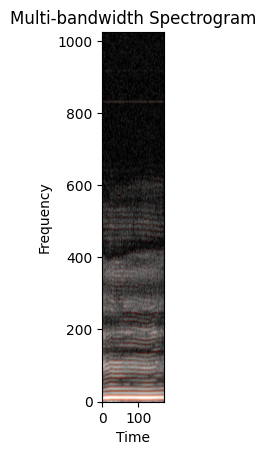

In [3]:
import matplotlib.pyplot as plt

# Testing out spectrograms.
# So many magic numbers in these Keras examples ...

# From https://keras.io/examples/audio/stft/#define-functions-to-read-and-preprocess-the-wav-files
def plot_multi_bandwidth_spectrogram(sample_wav_data):
    # All spectrograms must use the same `fft_length`, `frame_step`, and
    # `padding="same"` in order to produce spectrograms with identical shapes,
    # hence aligning them together. `expand_dims` ensures that the shapes are
    # compatible with image models.

    spectrograms = np.concatenate(
        [
            keras.layers.STFTSpectrogram(
                mode="log",
                frame_length=SAMPLE_RATE * x // 1000,
                frame_step=SAMPLE_RATE * 4 // 1000,
                fft_length=2048,
                padding="same",
                expand_dims=True,
            )(sample_wav_data[None, ...])[0, ...]
            for x in [8,16,20]
        ],
        axis=-1,
    ).transpose([1, 0, 2])

    # normalize each color channel for better viewing
    mn = spectrograms.min(axis=(0, 1), keepdims=True)
    mx = spectrograms.max(axis=(0, 1), keepdims=True)
    spectrograms = (spectrograms - mn) / (mx - mn)

    plt.imshow(spectrograms, origin="lower")
    plt.title("Multi-bandwidth Spectrogram")
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.show()

for sample in train:
    audio, label = sample
    plot_multi_bandwidth_spectrogram(audio)
    break



## Preprocessing
Let's instead convert the input to a 1D fft and train a dense

In [4]:
BLOCK_LENGTH  = 25000

# Preprocess dataset into blocks
@tf.function
def to_blocks(audio, label):
    audio = tf.squeeze(audio)
    num_blocks = tf.shape(audio)[0] // BLOCK_LENGTH
    
    def block_fn(i):
        start = i * BLOCK_LENGTH
        end = (i + 1) * BLOCK_LENGTH
        block = audio[start:end]
        block = tf.expand_dims(block, axis=-1)
        return block, label
    
    indices = tf.range(num_blocks)
    blocks, labels = tf.map_fn(block_fn, indices, fn_output_signature=(tf.TensorSpec([BLOCK_LENGTH, 1], tf.float32), tf.TensorSpec([1], label.dtype)))
    return tf.data.Dataset.from_tensor_slices((blocks, labels))

def dstoblocks(ds):
    return ds.flat_map(to_blocks)

train_blocks = dstoblocks(train).batch(32)
val_blocks = dstoblocks(val).batch(32)

In [5]:
for sample in val_blocks.take(1):
    audio, label = sample
    print(f"Label: {label.numpy()}")
    print(f"Audio shape: {audio.shape}")


Label: [[0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [1.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]
 [0.]
 [0.]]
Audio shape: (32, 25000, 1)


# Models


## STFT Based
Working from this example: https://keras.io/examples/audio/stft/

In [ ]:
input = keras.layers.Input((BLOCK_LENGTH, 1))
spectrograms = [
    keras.layers.STFTSpectrogram(
        mode="log",
        frame_length=BLOCK_LENGTH * frame_size // 1000,
        frame_step=BLOCK_LENGTH * 2 // 1000,
        fft_length=999,
        padding="same",
        expand_dims=True,
        trainable=False,
    )(input)
    for frame_size in [15, 20, 25]
]

multi_spectrograms = keras.layers.Concatenate(axis=-1)(spectrograms)

x = keras.layers.Conv2D(128, kernel_size=(3, 3), activation="relu", padding="same")(multi_spectrograms)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Conv2D(64, kernel_size=(3, 3), activation="relu", padding="same")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Conv2D(3, kernel_size=(3, 3), activation="relu", padding="same")(x)


x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Conv2D(16, kernel_size=(3, 3), activation="relu", padding="same")(x)
x = keras.layers.MaxPooling2D(pool_size=(2, 2), padding="same")(x)
x = keras.layers.Flatten()(x)
x = keras.layers.Dropout(0.5)(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dense(1, activation="sigmoid")(x)
output = x

model = keras.Model(input, output, name="model_2d_trainable_stft")

model.compile(loss="mae", optimizer="adam", metrics=["accuracy", tf.keras.metrics.F1Score(average=None, threshold=None, name='f1_score')])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/stft_spectrogram.py:164: UserWarning: `fft_length` is recommended to be a power of two. Received fft_length=999
  warnings.warn(


Model: "model_2d_trainable_stft"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 25000, 1)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_12 │ (None, 500, 500,  │    375,000 │ input_layer_3[0]… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_13 │ (None, 500, 500,  │    500,000 │ input_layer_3[0]… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stft_spectrogram_14 │ (None, 500, 500,  │    625,000 │ input_layer_3[0]… │
│ (STFTSpectrogram)   │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 500, 500,  │          0 │ stft_spectrogram… │
│ (Concatenate)       │ 3)                │            │ stft_spectrogram… │
│                     │                   │            │ stft_spectrogram… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 500, 500,  │        896 │ concatenate_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_18    │ (None, 250, 250,  │          0 │ conv2d_18[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 250, 250,  │      4,624 │ max_pooling2d_18… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_19    │ (None, 125, 125,  │          0 │ conv2d_19[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 125, 125,  │      2,320 │ max_pooling2d_19… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_20    │ (None, 63, 63,    │          0 │ conv2d_20[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 63, 63,    │      2,320 │ max_pooling2d_20… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_21    │ (None, 32, 32,    │          0 │ conv2d_21[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_22 (Conv2D)  │ (None, 32, 32,    │      2,320 │ max_pooling2d_21… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_22    │ (None, 16, 16,    │          0 │ conv2d_22[0][0]   │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_23 (Conv2D)  │ (None, 16, 16,    │      2,320 │ max_pooling2d_22… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,843,249 (7.03 MB)

 Trainable params: 343,249 (1.31 MB)

 Non-trainable params: 1,500,000 (5.72 MB)

In [13]:
checkpoint_path = "./model_best.keras"
if ON_COLAB:
    checkpoint_path = "/content/drive/My Drive/ai/model_best.keras"

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=False,
    mode="auto",
    verbose=1,
)

history = model.fit(
    train_blocks,
    epochs=250,
    validation_data=val_blocks,
    callbacks=[checkpoint_callback],
)

print(f"Best model saved to: {checkpoint_path}")

Epoch 1/250
     89/Unknown 13s 107ms/step - accuracy: 0.6478 - f1_score: 0.7858 - loss: 0.3572

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 1: val_loss improved from None to 0.30968, saving model to /content/drive/My Drive/ai/model_best.keras

Epoch 1: finished saving model to /content/drive/My Drive/ai/model_best.keras
90/90 ━━━━━━━━━━━━━━━━━━━━ 14s 120ms/step - accuracy: 0.6548 - f1_score: 0.7914 - loss: 0.3462 - val_accuracy: 0.6903 - val_f1_score: 0.8168 - val_loss: 0.3097
Epoch 2/250
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6696 - f1_score: 0.8019 - loss: 0.3304
Epoch 2: val_loss did not improve from 0.30968
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.6548 - f1_score: 0.7914 - loss: 0.3452 - val_accuracy: 0.6903 - val_f1_score: 0.8168 - val_loss: 0.3097
Epoch 3/250
89/90 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step - accuracy: 0.6535 - f1_score: 0.7903 - loss: 0.3465
Epoch 3: val_loss did not improve from 0.30968
90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - accuracy: 0.6548 - f1_score: 0.7914 - loss: 0.3452 - val_accuracy: 0.6903 - val_f1_score: 0.8168 - val_loss: 0.3097
Epoch 4/250
89/90 ━━━━━━━

In [14]:
y_prediction = model.predict(train_blocks)
print(y_prediction)

90/90 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step
[[1.]
 [1.]
 [1.]
 ...
 [1.]
 [1.]
 [1.]]
